# Has the world decoupled growth from carbon?

**Week 13 mini-project — reference solution.**

Every climate argument eventually reaches the same objection: *cutting emissions
means cutting growth*. That is a testable claim, and the data to test it is
free. This notebook uses Our World in Data's CO2 dataset — 50,411 country-years
of emissions, population and GDP going back to 1750 — to ask three questions:

1. What is the world actually burning, and how has that mix changed since 1950?
2. Who emits the most today, in total and per person?
3. Between 1990 and 2022, which large emitters grew their economy *while*
   cutting emissions — "absolute decoupling" — and did those cuts add up to
   anything globally?

The dataset is pinned to a specific commit and checksummed, so every number
below is reproducible byte-for-byte. See `fetch_data.py`.

## 1. Load

`fetch_data.load_raw()` downloads the pinned CSV into `data/` on first run,
verifies its SHA-256, and hands back the untouched table. Re-running the
notebook uses the cache.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fetch_data import load_raw

%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

raw = load_raw()
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

50,411 rows x 79 columns


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,...,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Inspect

79 columns is more than anyone needs. These 14 carry the whole analysis, so
inspect those and ignore the rest. Units, from the OWID codebook:

| Column | Unit |
|---|---|
| `co2`, `*_co2` | million tonnes of CO2 per year |
| `co2_per_capita` | tonnes of CO2 per person per year |
| `gdp` | international-\$ (2011 PPP), from the Maddison Project |
| `population` | people |
| `share_global_co2` | percent of that year's world total |

In [2]:
FUELS = [
    "coal_co2", "oil_co2", "gas_co2",
    "cement_co2", "flaring_co2", "other_industry_co2",
]
COLS = [
    "country", "iso_code", "year",
    "population", "gdp", "co2", "co2_per_capita", "share_global_co2",
] + FUELS

raw[COLS].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             50411 non-null  object 
 1   iso_code            42480 non-null  object 
 2   year                50411 non-null  int64  
 3   population          41167 non-null  float64
 4   gdp                 15251 non-null  float64
 5   co2                 29384 non-null  float64
 6   co2_per_capita      26509 non-null  float64
 7   share_global_co2    27563 non-null  float64
 8   coal_co2            21925 non-null  float64
 9   oil_co2             25459 non-null  float64
 10  gas_co2             18147 non-null  float64
 11  cement_co2          29173 non-null  float64
 12  flaring_co2         16174 non-null  float64
 13  other_industry_co2  3254 non-null   float64
dtypes: float64(11), int64(1), object(2)
memory usage: 5.4+ MB


In [3]:
# Missing-data audit. Never skip this: it decides what the analysis can ask.
missing = raw[COLS].isna().sum().sort_values(ascending=False)
audit = pd.DataFrame({
    "n_missing": missing,
    "pct_missing": (missing / len(raw) * 100).round(1),
    "dtype": raw[COLS].dtypes[missing.index].astype(str),
})
audit

,n_missing,pct_missing,dtype
other_industry_co2,47157,93.5,float64
gdp,35160,69.7,float64
flaring_co2,34237,67.9,float64
gas_co2,32264,64.0,float64
coal_co2,28486,56.5,float64
oil_co2,24952,49.5,float64
co2_per_capita,23902,47.4,float64
share_global_co2,22848,45.3,float64
cement_co2,21238,42.1,float64
co2,21027,41.7,float64


In [4]:
# How far does each column actually reach in time? This is the constraint that
# sets the analysis window.
for col in ["co2", "population", "gdp"]:
    ok = raw.loc[raw[col].notna(), "year"]
    print(f"{col:12s} {ok.min():.0f} - {ok.max():.0f}   ({raw[col].notna().sum():,} values)")

co2          1750 - 2024   (29,384 values)
population   1750 - 2024   (41,167 values)
gdp          1820 - 2022   (15,251 values)


In [5]:
raw.loc[raw["year"] >= 1950, ["co2", "co2_per_capita", "population", "gdp"]].describe().round(2)

,co2,co2_per_capita,population,gdp
count,17547.00,16493.00,1.717500e+04,1.147200e+04
mean,613.26,5.35,9.159792e+07,4.130017e+11
std,2502.08,17.72,4.724101e+08,3.552073e+12
min,0.00,0.00,5.010000e+02,4.998000e+07
25%,0.68,0.46,5.286090e+05,8.479572e+09
50%,7.97,2.15,4.466330e+06,3.224005e+10
75%,86.60,6.59,1.754178e+07,1.532196e+11
max,38598.58,782.74,8.161973e+09,1.301126e+14


### What the audit tells us

- **`gdp` stops at 2022.** Anything comparing money to carbon has to end there.
  Emissions themselves run to 2024, so the fuel-mix chart can use the full range.
- **`iso_code` is missing on 7,931 rows.** Those are not broken records — they
  are OWID's *aggregate* rows: `World`, `Africa`, `European Union (27)`,
  `High-income countries`, `International shipping`, and so on. Leaving them in
  would double-count every country. They are the single most common way to get
  a wrong answer from this dataset.
- **`other_industry_co2` is 93.5% missing** yet must stay: where it is present it
  is a real part of the total, and the six fuel columns sum to `co2` to within
  0.001 Mt on average. Missing here means "no recorded emissions from this
  source", not "unknown", so filling with 0 is correct — a rare case where it is.

## 3. Clean

Six decisions, each one stated so a reader can disagree with it:

1. **Keep only rows with an `iso_code`.** Drops the 36 aggregate entities. It
   also drops Kosovo and the Ryukyu Islands, which are real places without an
   ISO-3166 alpha-3 code — 0.01% of the emissions we keep, and worth the trade
   to be certain nothing is double-counted.
2. **Window to 1950–2024.** Pre-1950 country coverage is patchy enough that a
   "world total" built by summing countries is misleading.
3. **Keep 14 columns**, drop 65.
4. **Fill the six fuel columns with 0**, justified above. Verified in the next
   cell rather than asserted.
5. **`country` to `category`, `year` to `int16`.** Deep memory use drops from
   ~3.3 MB to ~2.3 MB and the groupbys get faster.
6. **Drop rows with no `co2` at all.** Nothing downstream can use them.

In [6]:
df = raw.loc[raw["iso_code"].notna(), COLS].copy()
df = df[df["year"].between(1950, 2024)].copy()

df[FUELS] = df[FUELS].fillna(0.0)

df["year"] = df["year"].astype("int16")
df["country"] = df["country"].astype("category")

# Derived columns
df["gdp_per_capita"] = df["gdp"] / df["population"]
df["decade"] = (df["year"] // 10 * 10).astype("int16")

df = df.dropna(subset=["co2"])

print(f"{len(df):,} rows, {df['country'].nunique()} countries, "
      f"{df['year'].min()}-{df['year'].max()}")
df.head()

15,270 rows, 215 countries, 1950-2024


,country,iso_code,year,population,gdp,co2,co2_per_capita,share_global_co2,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,other_industry_co2,gdp_per_capita,decade
200,Afghanistan,AFG,1950,7776180.0,9.421400e+09,0.084,0.011,0.001,0.021,0.063,0.0,0.0,0.0,0.0,1211.571749,1950
201,Afghanistan,AFG,1951,7879343.0,9.692280e+09,0.092,0.012,0.001,0.026,0.066,0.0,0.0,0.0,0.0,1230.087331,1950
202,Afghanistan,AFG,1952,7987784.0,1.001732e+10,0.092,0.011,0.001,0.032,0.060,0.0,0.0,0.0,0.0,1254.080606,1950
203,Afghanistan,AFG,1953,8096703.0,1.063052e+10,0.106,0.013,0.002,0.038,0.068,0.0,0.0,0.0,0.0,1312.944293,1950
204,Afghanistan,AFG,1954,8207954.0,1.086636e+10,0.106,0.013,0.002,0.043,0.064,0.0,0.0,0.0,0.0,1323.881688,1950


In [7]:
# Verify decision 4 instead of trusting it: do the six components sum to the total?
residual = df["co2"] - df[FUELS].sum(axis=1)
print(f"largest single-row discrepancy: {residual.abs().max():.3f} Mt")
print(f"mean absolute discrepancy:      {residual.abs().mean():.6f} Mt")
print(f"rows off by more than 0.01 Mt:  {(residual.abs() > 0.01).sum()}")

largest single-row discrepancy: 1.436 Mt
mean absolute discrepancy:      0.000380 Mt
rows off by more than 0.01 Mt:  1


### One caveat to carry forward

Summing countries is **not** the same as OWID's `World` row. In 2023 the
country sum is 37,003 Mt against a World figure of 38,094 Mt. The 1,091 Mt gap
is almost entirely international aviation and shipping — fuel burned in
international airspace and waters, which belongs to no country's inventory.
Every "world" number below is a country sum, and therefore excludes bunkers.
Say so in the write-up rather than letting a reader assume otherwise.

## 4. Analyze

Three aggregations, in increasing order of interest.

### 4a. World fuel mix by decade — `melt` then `pivot_table`

The six fuel columns are *wide*: one column per source. `pivot_table` wants a
long frame with a single `source` column, so `melt` first. This
wide -> long -> wide round trip is the most common reshaping move in pandas.

In [8]:
long = df.melt(
    id_vars=["country", "year", "decade"],
    value_vars=FUELS,
    var_name="source",
    value_name="mt",
)
long["source"] = (long["source"]
                  .str.replace("_co2", "", regex=False)
                  .str.replace("other_industry", "other industry", regex=False))

fuel_by_decade = long.pivot_table(
    index="decade",
    columns="source",
    values="mt",
    aggfunc="sum",
    fill_value=0.0,
)[["coal", "oil", "gas", "cement", "flaring", "other industry"]]

# 2020s is a partial decade (2020-2024); annualise it so the bars compare fairly.
years_per_decade = df.groupby("decade", observed=True)["year"].nunique()
fuel_per_year = fuel_by_decade.div(years_per_decade, axis=0)
fuel_per_year.round(0)

source,coal,oil,gas,cement,flaring,other industry
decade,,,,,,
1950,4335.0,2046.0,544.0,103.0,90.0,6.0
1960,5207.0,4045.0,1216.0,210.0,138.0,34.0
1970,6074.0,7706.0,2246.0,346.0,360.0,49.0
1980,7847.0,8104.0,3035.0,435.0,204.0,61.0
1990,8674.0,8852.0,4159.0,592.0,300.0,338.0
2000,11174.0,9848.0,5308.0,945.0,339.0,365.0
2010,14634.0,10579.0,6802.0,1449.0,381.0,408.0
2020,15219.0,10828.0,7794.0,1576.0,406.0,425.0


In [9]:
# Share of the annual total, by decade — the shape of the energy transition.
share = (fuel_per_year.div(fuel_per_year.sum(axis=1), axis=0) * 100).round(1)
share

source,coal,oil,gas,cement,flaring,other industry
decade,,,,,,
1950,60.9,28.7,7.6,1.4,1.3,0.1
1960,48.0,37.3,11.2,1.9,1.3,0.3
1970,36.2,45.9,13.4,2.1,2.1,0.3
1980,39.9,41.2,15.4,2.2,1.0,0.3
1990,37.9,38.6,18.2,2.6,1.3,1.5
2000,39.9,35.2,19.0,3.4,1.2,1.3
2010,42.7,30.9,19.9,4.2,1.1,1.2
2020,42.0,29.9,21.5,4.3,1.1,1.2


### 4b. Who emits the most today — named aggregation over a groupby

`groupby(...).agg(name=(column, func))` is the modern form: it names the output
columns instead of leaving you with a MultiIndex to unpick.

In [10]:
latest = df[df["year"] == 2023]

top15 = (latest
         .groupby("country", observed=True)
         .agg(co2_mt=("co2", "sum"),
              per_capita_t=("co2_per_capita", "max"),
              share_pct=("share_global_co2", "max"),
              population=("population", "max"))
         .nlargest(15, "co2_mt")
         .round(2))

top15["cumulative_share_pct"] = top15["share_pct"].cumsum().round(1)
top15

,co2_mt,per_capita_t,share_pct,population,cumulative_share_pct
country,,,,,
China,12172.01,8.56,31.95,1.422585e+09,32.0
United States,4918.41,14.32,12.91,3.434773e+08,44.9
India,3062.76,2.13,8.04,1.438070e+09,52.9
Russia,1733.14,11.92,4.55,1.454405e+08,57.4
Japan,986.91,7.94,2.59,1.243709e+08,60.0
Iran,789.68,8.72,2.07,9.060871e+07,62.1
Indonesia,762.36,2.71,2.00,2.811901e+08,64.1
Saudi Arabia,677.44,20.36,1.78,3.326429e+07,65.9
Germany,593.77,7.02,1.56,8.454823e+07,67.4


In [11]:
print(f"Top 15 countries = {top15['share_pct'].sum():.1f}% of the 2023 world total.")
print(f"China alone      = {top15.loc['China', 'share_pct']:.1f}%.")
print()
print("Same 15 countries, ranked by tonnes per person instead:")
top15[["co2_mt", "per_capita_t"]].sort_values("per_capita_t", ascending=False).head(6)

Top 15 countries = 75.3% of the 2023 world total.
China alone      = 31.9%.

Same 15 countries, ranked by tonnes per person instead:


,co2_mt,per_capita_t
country,,
Saudi Arabia,677.44,20.36
United States,4918.41,14.32
Canada,545.48,13.88
Russia,1733.14,11.92
South Korea,589.18,11.38
Iran,789.68,8.72


### 4c. Decoupling, 1990 to 2022 — the actual question

For every country with both a `co2` and a `gdp` figure in 1990 *and* 2022,
compute the percentage change in each. Then classify:

| Class | Test | Meaning |
|---|---|---|
| **absolute decoupling** | GDP up, CO2 **down** | grew richer, burned less |
| **relative decoupling** | GDP up, CO2 up but by less | grew more efficient, still growing emissions |
| **coupled** | CO2 up at least as fast as GDP | no efficiency gain at all |
| **no growth** | GDP flat or down | the comparison is not meaningful |

`pivot_table` with two `values` columns gives a MultiIndex on the columns;
flattening it to `co2_1990`, `gdp_2022`, ... makes the arithmetic readable.

In [12]:
pair = df[df["year"].isin([1990, 2022])].dropna(subset=["co2", "gdp"])

wide = pair.pivot_table(index="country", columns="year", values=["co2", "gdp"], observed=True)
wide.columns = [f"{metric}_{year}" for metric, year in wide.columns]
wide = wide.dropna()

wide["co2_pct"] = (wide["co2_2022"] / wide["co2_1990"] - 1) * 100
wide["gdp_pct"] = (wide["gdp_2022"] / wide["gdp_1990"] - 1) * 100
wide["co2_delta_mt"] = wide["co2_2022"] - wide["co2_1990"]


def classify(row: pd.Series) -> str:
    if row["gdp_pct"] <= 0:
        return "no growth"
    if row["co2_pct"] < 0:
        return "absolute decoupling"
    if row["co2_pct"] < row["gdp_pct"]:
        return "relative decoupling"
    return "coupled"


wide["status"] = wide.apply(classify, axis=1)

big20 = wide.nlargest(20, "co2_1990")
big20[["co2_1990", "co2_2022", "co2_pct", "gdp_pct", "status"]].round(1)

,co2_1990,co2_2022,co2_pct,gdp_pct,status
country,,,,,
United States,5131.8,5055.4,-1.5,110.7,absolute decoupling
Russia,2536.3,1675.5,-33.9,103.4,absolute decoupling
China,2483.5,11711.8,371.6,696.6,relative decoupling
Japan,1154.9,1029.6,-10.8,29.0,absolute decoupling
Germany,1054.8,667.8,-36.7,94.0,absolute decoupling
Ukraine,706.5,143.0,-79.8,-37.7,no growth
United Kingdom,601.9,311.1,-48.3,73.7,absolute decoupling
India,578.0,2831.1,389.8,498.3,relative decoupling
Canada,458.0,547.7,19.6,110.7,relative decoupling


In [13]:
print(big20["status"].value_counts().to_string())
print()

decouplers = big20[big20["status"] == "absolute decoupling"]
saved = decouplers["co2_delta_mt"].sum()
china = wide.loc["China", "co2_delta_mt"]

print(f"The {len(decouplers)} absolute decouplers among the 20 largest 1990 emitters")
print(f"cut a combined {abs(saved):,.0f} Mt/year between 1990 and 2022.")
print(f"China's emissions rose {china:,.0f} Mt/year over the same period")
print(f"— {china / abs(saved):.1f}x the size of every one of those cuts put together.")

status
relative decoupling    11
absolute decoupling     8
no growth               1

The 8 absolute decouplers among the 20 largest 1990 emitters
cut a combined 1,999 Mt/year between 1990 and 2022.
China's emissions rose 9,228 Mt/year over the same period
— 4.6x the size of every one of those cuts put together.


In [14]:
# Global carbon intensity: how much CO2 per dollar of world output?
world = raw[raw["country"] == "World"].set_index("year")
i1990 = world.loc[1990, "co2"] * 1e6 / world.loc[1990, "gdp"]
i2022 = world.loc[2022, "co2"] * 1e6 / world.loc[2022, "gdp"]

print(f"World GDP 1990 -> 2022: {(world.loc[2022, 'gdp'] / world.loc[1990, 'gdp'] - 1) * 100:+.1f}%")
print(f"World CO2 1990 -> 2022: {(world.loc[2022, 'co2'] / world.loc[1990, 'co2'] - 1) * 100:+.1f}%")
print(f"Carbon intensity:       {(i2022 / i1990 - 1) * 100:+.1f}%  "
      f"({i1990 * 1000:.3f} -> {i2022 * 1000:.3f} kg CO2 per international-$)")

World GDP 1990 -> 2022: +202.4%
World CO2 1990 -> 2022: +65.1%
Carbon intensity:       -45.4%  (0.528 -> 0.288 kg CO2 per international-$)


## 5. Visualize

Four charts. Every one gets a title, axis labels with units, and a legend where
there is more than one series.

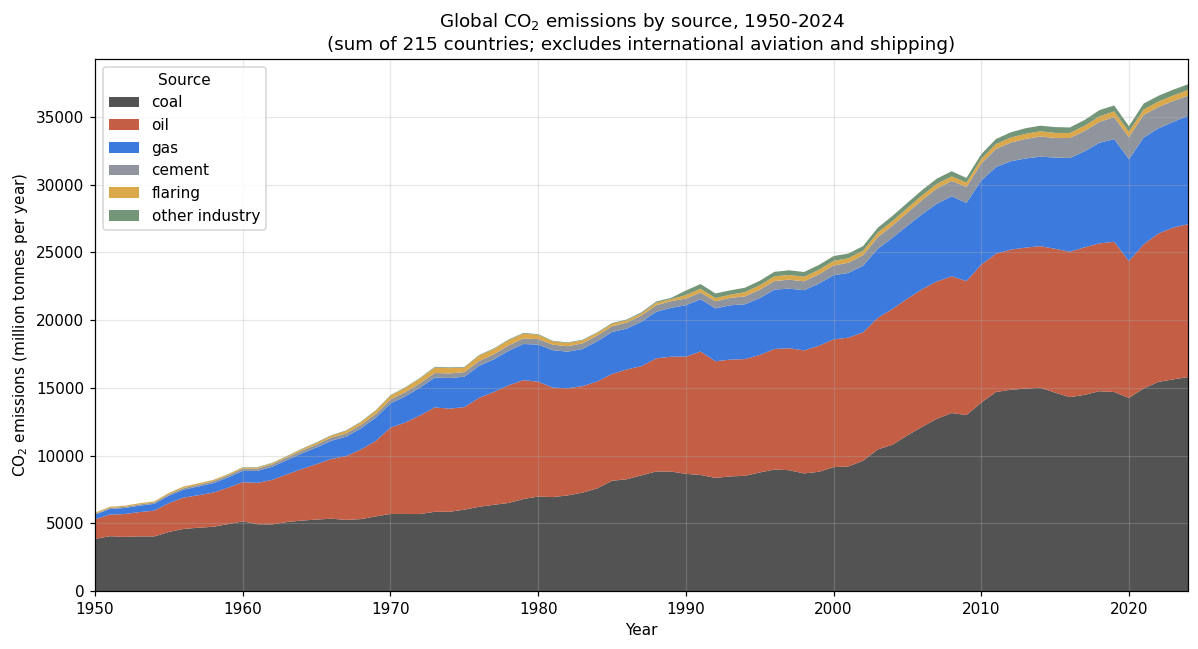

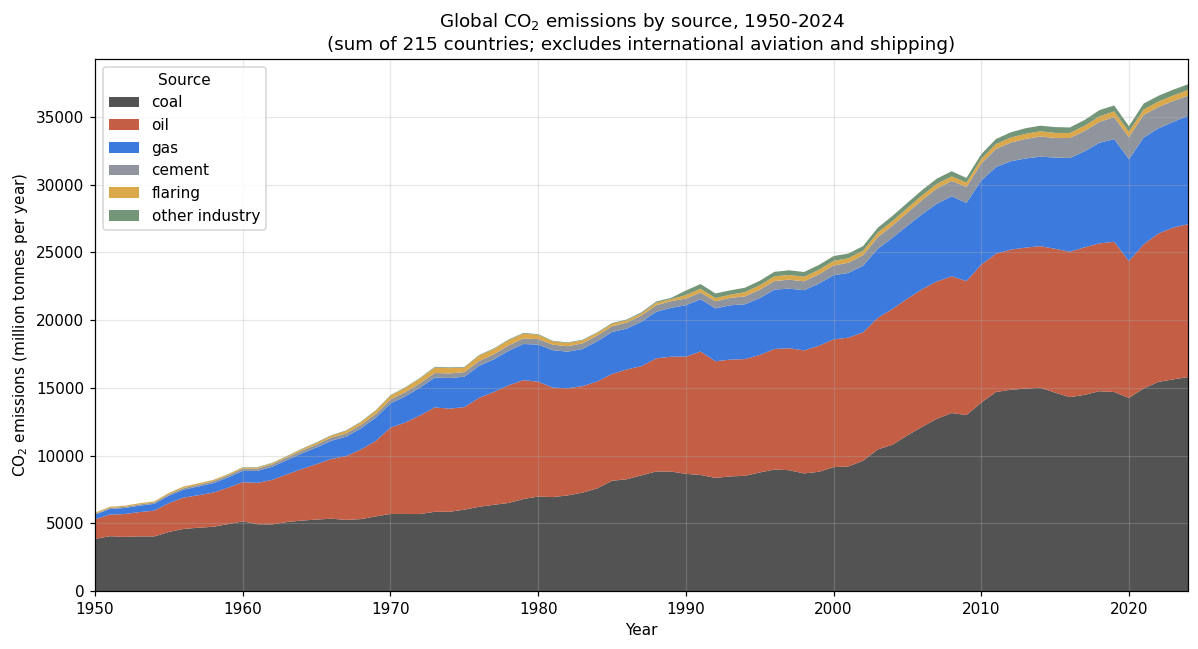

In [15]:
# Chart 1 (figures/main.png) — what the world burns, and when it changed.
annual = (df.groupby("year", observed=True)[FUELS].sum()
            .rename(columns=lambda c: c.replace("_co2", "").replace("other_industry", "other industry")))
annual = annual[["coal", "oil", "gas", "cement", "flaring", "other industry"]]

colors = ["#4a4a4a", "#c1553b", "#3273dc", "#8a8f98", "#d9a441", "#6b8f71"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(annual.index, annual.T.values, labels=annual.columns, colors=colors, alpha=0.95)
ax.set_title("Global CO$_2$ emissions by source, 1950-2024\n"
             "(sum of 215 countries; excludes international aviation and shipping)")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ emissions (million tonnes per year)")
ax.set_xlim(1950, 2024)
ax.set_ylim(0, None)
ax.legend(loc="upper left", title="Source")
fig.tight_layout()
fig.savefig(FIGURES / "main.png", dpi=150, bbox_inches="tight")
fig

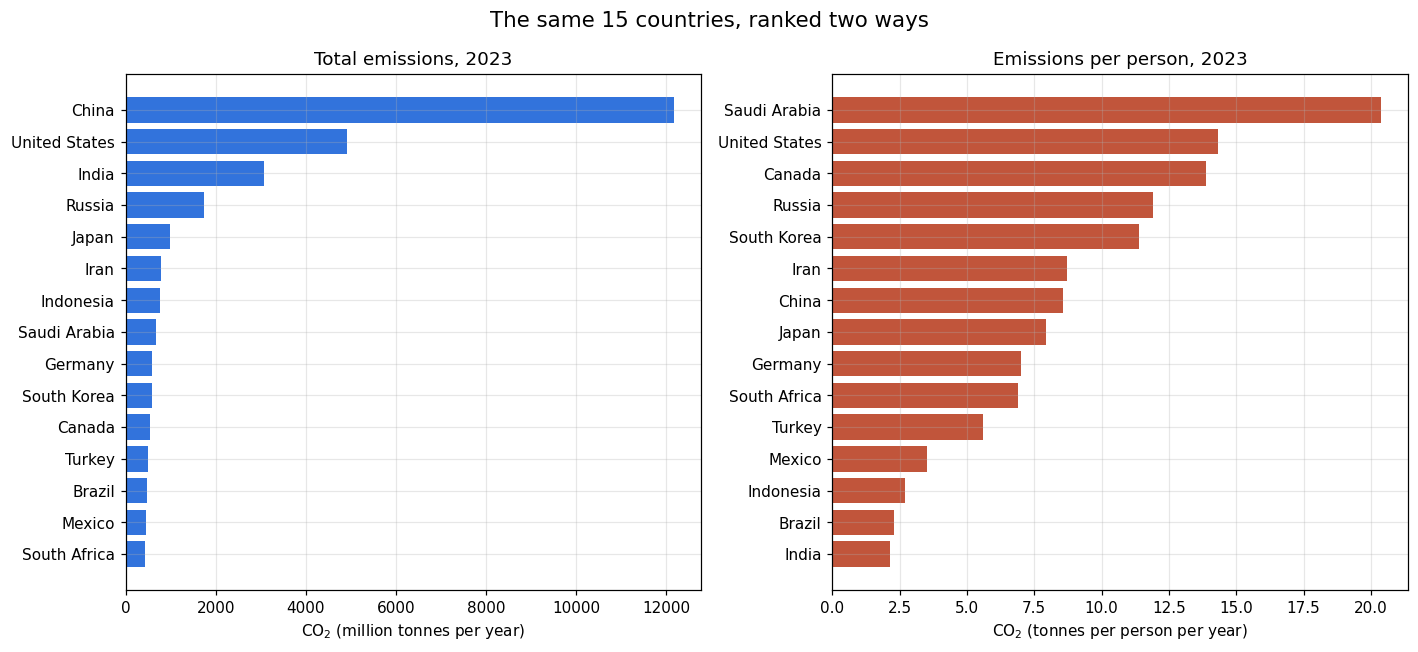

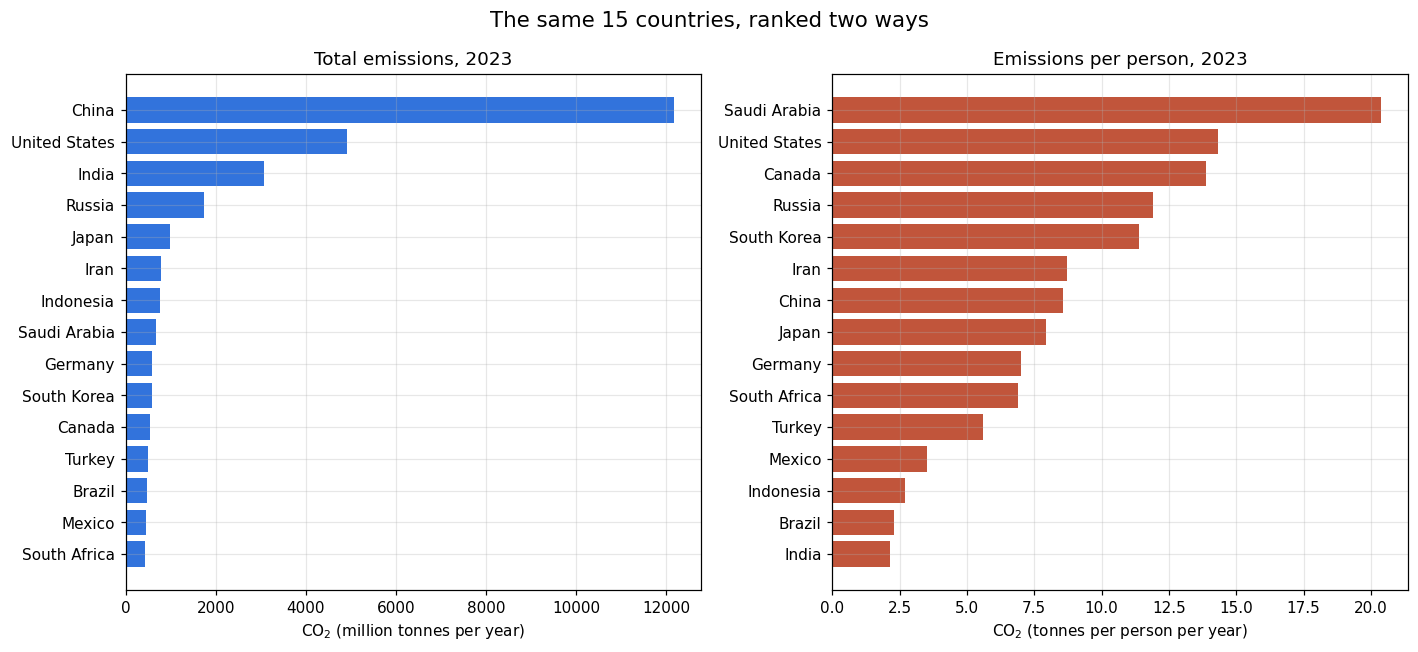

In [16]:
# Chart 2 — total vs per-person, side by side. The ranking inverts.
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

t = top15.sort_values("co2_mt")
axes[0].barh(t.index.astype(str), t["co2_mt"], color="#3273dc")
axes[0].set_title("Total emissions, 2023")
axes[0].set_xlabel("CO$_2$ (million tonnes per year)")

p = top15.sort_values("per_capita_t")
axes[1].barh(p.index.astype(str), p["per_capita_t"], color="#c1553b")
axes[1].set_title("Emissions per person, 2023")
axes[1].set_xlabel("CO$_2$ (tonnes per person per year)")

fig.suptitle("The same 15 countries, ranked two ways", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / "top15-total-vs-per-capita.png", dpi=150, bbox_inches="tight")
fig

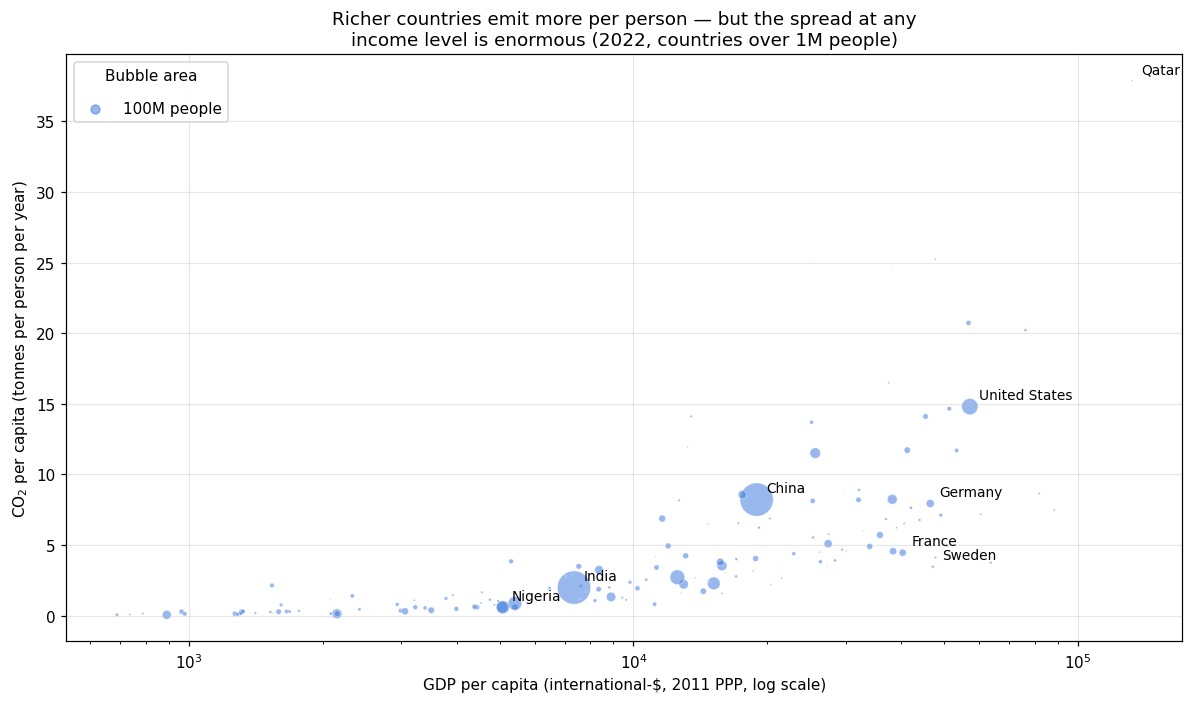

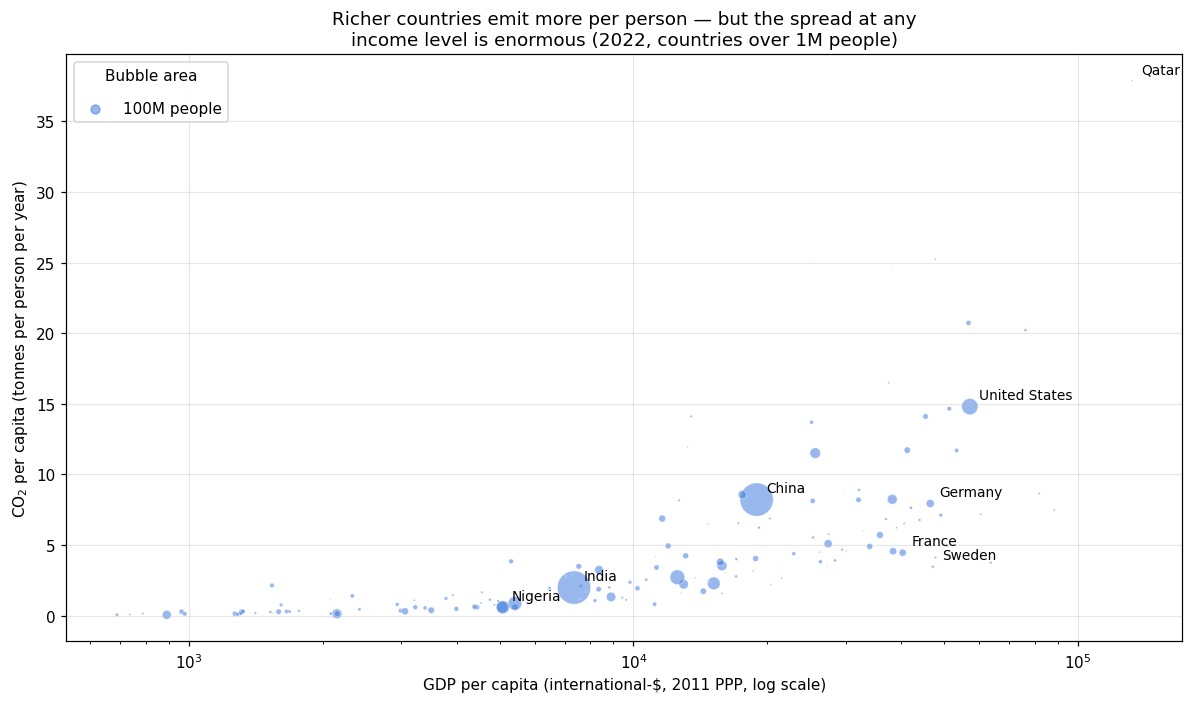

In [17]:
# Chart 3 — income against carbon, 2022. Log x because GDP per capita spans 300x.
s = (df[(df["year"] == 2022)]
     .dropna(subset=["gdp_per_capita", "co2_per_capita", "population"])
     .query("population > 1e6"))

fig, ax = plt.subplots(figsize=(11, 6.5))
sc = ax.scatter(s["gdp_per_capita"], s["co2_per_capita"],
                s=s["population"] / 3e6, alpha=0.5,
                color="#3273dc", edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("GDP per capita (international-$, 2011 PPP, log scale)")
ax.set_ylabel("CO$_2$ per capita (tonnes per person per year)")
ax.set_title("Richer countries emit more per person — but the spread at any\n"
             "income level is enormous (2022, countries over 1M people)")

for name in ["United States", "China", "India", "Germany", "Qatar", "Nigeria", "France", "Sweden"]:
    if name in set(s["country"].astype(str)):
        row = s[s["country"] == name].iloc[0]
        ax.annotate(name, (row["gdp_per_capita"], row["co2_per_capita"]),
                    textcoords="offset points", xytext=(6, 5), fontsize=9)

ax.scatter([], [], s=100e6 / 3e6, color="#3273dc", alpha=0.5, label="100M people")
ax.legend(loc="upper left", scatterpoints=1, labelspacing=1.2, title="Bubble area")
fig.tight_layout()
fig.savefig(FIGURES / "income-vs-carbon.png", dpi=150, bbox_inches="tight")
fig

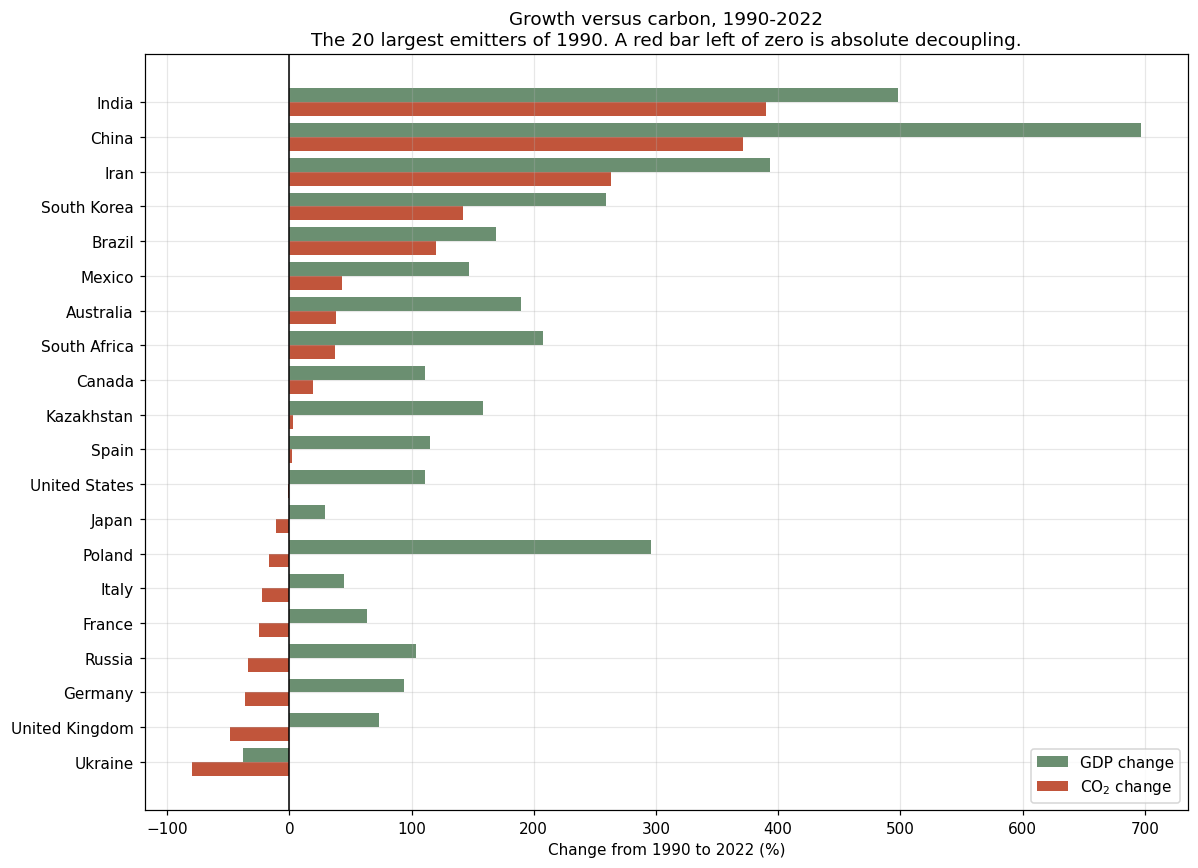

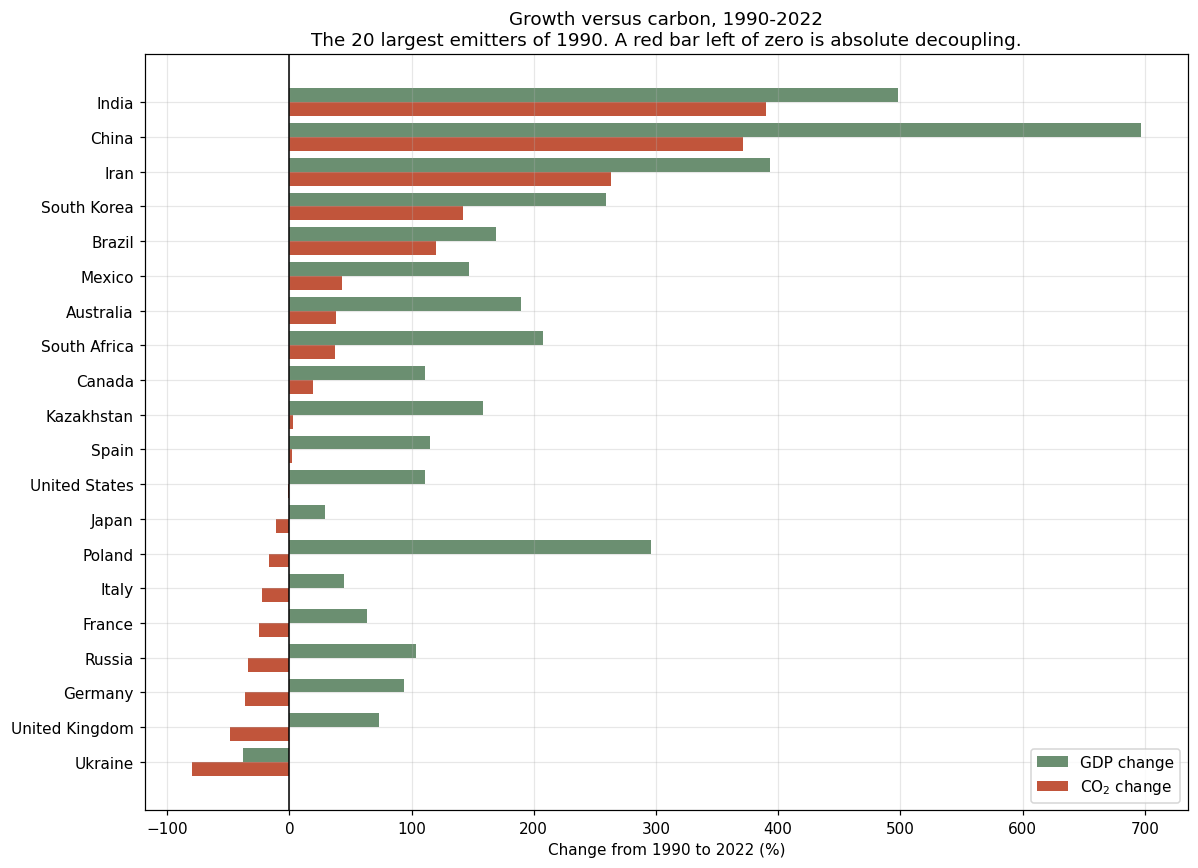

In [18]:
# Chart 4 — the decoupling answer, as a diverging bar.
d = big20.sort_values("co2_pct")
y = np.arange(len(d))
height = 0.4

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(y + height / 2, d["gdp_pct"], height, label="GDP change", color="#6b8f71")
ax.barh(y - height / 2, d["co2_pct"], height, label="CO$_2$ change", color="#c1553b")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(d.index.astype(str))
ax.set_xlabel("Change from 1990 to 2022 (%)")
ax.set_ylabel("")
ax.set_title("Growth versus carbon, 1990-2022\n"
             "The 20 largest emitters of 1990. A red bar left of zero is absolute decoupling.")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "decoupling-1990-2022.png", dpi=150, bbox_inches="tight")
fig

## 6. Conclude

**Yes, decoupling is real — and no, it is not yet happening fast enough to
matter.** Of the twenty largest emitters of 1990, eight cut their absolute CO2
output by 2022 while growing their economies: the United Kingdom cut 48.3% on
73.7% GDP growth, Germany 36.7% on 94.0%, and even the United States managed a
1.5% cut on 110.7% growth. That kills the "emissions are the price of growth"
argument outright.

But the arithmetic of the whole is brutal. Those eight countries removed about
**1,999 Mt of CO2 per year** between them. China added **9,228 Mt** over the
same period — 4.6 times every one of those cuts combined. World GDP grew 202.4%
while world CO2 grew 65.1%, so the *carbon intensity* of world output fell
45.4%: the global economy is far more efficient per dollar and is still emitting
more every year, because there are far more dollars.

If I had another week, I would swap `co2` for `consumption_co2` — emissions
attributed to where goods are *consumed* rather than where they are made. That
column only starts in 1990 and covers fewer countries, but it directly tests the
obvious objection to the finding above: that Britain and Germany "decarbonised"
partly by importing steel and electronics from China. Comparing the two series
country by country would show how much of European decoupling is real and how
much is bookkeeping.

The one-page write-up is in [`findings.md`](./findings.md).